# R1.3 -- IoU vs. rotation mismatch (Reviewer 2, comment 2)

Imports the consolidated `functions.py` module (Sections 1-3: rotation-sweep analysis, DSB-Hungarian matching, orientation-mismatch diagnostics).

**Note on `debug_flag`**: functions inside `functions.py` check the module's own global `debug_flag`, not a notebook-local variable. Set it via `fn.debug_flag = False`, not a bare `debug_flag = False` -- see the module docstring for why the latter would silently fail to take effect.

In [1]:
import os
import functions as fn
import importlib
importlib.reload(fn)
fn.debug_flag = False  


c:\Users\abd93000\PycharmProjects\cnt_project_v2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
path_gt = "..\\..\\..\\data\\cnt_segmentation\\COCO_mask\\all_images\\test"
gt_json = "annotations_chain_approx_none.json"
path_pred = "..\\..\\..\\global_outputs\\runs\\fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004\\inference"
pred_json = 'predicted_annotations_poly.json'

## Load GT and run the rotation sweep (Experiments A + B)

In [ ]:
max_instances = 10
df = fn.run_rotation_sweep(os.path.join(path_gt, gt_json), scoring_method="iou", max_instances=max_instances)
print(df.groupby("theta")[["empirical_overlap_score", "rod_model"]].mean())


loading annotations into memory...
Done (t=0.90s)
creating index...
index created!
       empirical_overlap_score  rod_model
theta                                    
0                     1.000000   1.000000
1                     0.916655   0.881537
2                     0.760180   0.777929
3                     0.607417   0.687036
4                     0.493892   0.615179
5                     0.408755   0.554114
6                     0.353372   0.501020
7                     0.320651   0.458347
8                     0.284808   0.418348
9                     0.249745   0.384912
10                    0.223905   0.356624
11                    0.198142   0.331444
12                    0.178495   0.305990
13                    0.163966   0.286395
14                    0.149436   0.267480
15                    0.138871   0.253013
16                    0.131040   0.236734
17                    0.123427   0.226904
18                    0.121015   0.215150
19                    0.114302   0.

## Match GT<->predictions and record observed (theta, IoU) points (Experiment C)

In [78]:
import importlib
importlib.reload(fn)
import functions as fn
observed_df = fn.match_gt_pred_observed_points(
    os.path.join(path_gt, gt_json), os.path.join(path_pred, pred_json), scoring_method="iou", debug_plot_path="debug_plots_length", debug_n_examples=8
)

loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
loading annotations into memory...
Done (t=0.45s)
creating index...
index created!


Processing: 100%|██████████| 30/30 [04:23<00:00,  8.78s/it]


Saved debug plot to debug_plots_length


In [ ]:
from pycocotools.coco import COCO

importlib.reload(fn)

k = 10
TITLE_EXPERIMENT = "debug_plots_max_length_subset"
subset_df = (
    observed_df[
        # (observed_df["observed_overlap_score"] < 0.5)
        # & (observed_df["observed_theta_diff"] < 5) &
         (observed_df["observed_length_diff"] > 1.5)
    ]
    .sample(k)
)

# Load COCO annotations
gt_coco = COCO(os.path.join(path_gt, gt_json))
pred_coco = COCO(os.path.join(path_pred, pred_json))

debug_crops = []

for _, row in subset_df.iterrows():

    gt_ann = gt_coco.loadAnns([int(row["gt_ann_id"])])[0]
    pred_ann = pred_coco.loadAnns([int(row["pred_ann_id"])])[0]

    gt_mask = fn.ann_to_mask(gt_coco, gt_ann)
    pred_mask = fn.ann_to_mask(pred_coco, pred_ann)

    debug_crops.append({
        "filename": row["filename"],
        "gt_image_id": row["gt_image_id"],
        "pred_image_id": row["pred_image_id"],

        "gt_ann_id": row["gt_ann_id"],
        "pred_ann_id": row["pred_ann_id"],

        "gt_mask": gt_mask,
        "pred_mask": pred_mask,

        "gt_ori": row["gt_ori"],
        "pred_ori": row["pred_ori"],

        "gt_length": row["gt_length"],
        "pred_length": row["pred_length"],

        "observed_theta_diff": row["observed_theta_diff"],
        "observed_length_diff": row["observed_length_diff"],
        "observed_overlap_score": row["observed_overlap_score"],
    })

fn._plot_matched_examples(
    debug_crops,
    TITLE_EXPERIMENT,
    len(debug_crops),
    "observed_theta_diff",
    "observed_overlap_score",
    figsize=(6.0, 4.0),
)


loading annotations into memory...


Done (t=5.47s)
creating index...
index created!
loading annotations into memory...
Done (t=13.31s)
creating index...
index created!
Saved debug plot to debug_plots_max_length_subset


## Plot: IoU vs. rotation mismatch, actual dataset aspect-ratio distribution

In [53]:
df

,ann_id,theta,length,width,aspect_ratio,empirical_overlap_score,rod_model
0,1,0,95.798990,2.404061,39.848818,1.000000,1.000000
1,1,1,95.798990,2.404061,39.848818,0.779817,1.000000
2,1,1,95.798990,2.404061,39.848818,0.776000,1.000000
3,1,2,95.798990,2.404061,39.848818,0.617873,0.757938
4,1,2,95.798990,2.404061,39.848818,0.630899,0.757938
...,...,...,...,...,...,...,...
40954,1000,18,9.899495,2.710080,3.652842,0.873864,0.939759
40955,1000,19,9.899495,2.710080,3.652842,0.815534,0.898876
40956,1000,19,9.899495,2.710080,3.652842,0.844131,0.898876
40957,1000,20,9.899495,2.710080,3.652842,0.815534,0.921348


In [73]:
observed_df['observed_theta_diff']

0      0.121049
1      1.891581
2      4.180596
3      1.887415
4      2.305420
5      5.837199
6      7.758533
7     13.612653
8      0.805624
9      6.566825
10     1.933048
11     3.490328
12     1.801817
13    14.284868
Name: observed_theta_diff, dtype: float64

Saved figure to fig_iou_vs_theta_DSB_all_length.png


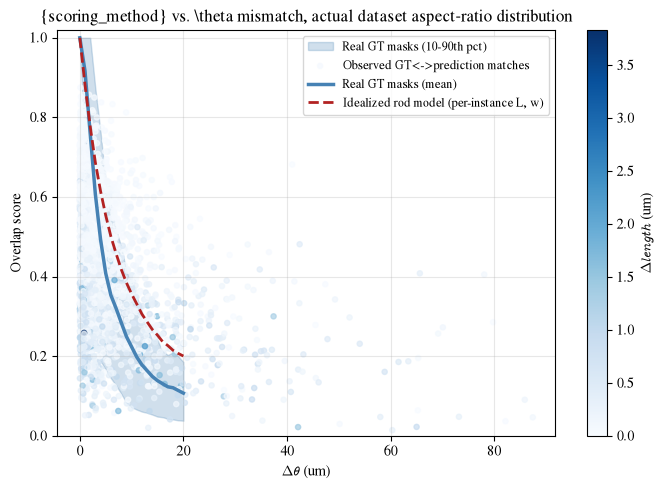

In [ ]:
importlib.reload(fn)
import scienceplots
plt.style.use(['no-latex'])
fn.plot_results(df, observed_df, "iou", "fig_iou_vs_theta_DSB_all_length.png", figsize)


In [127]:
256/3

85.33333333333333

Saved figure to fig_iou_vs_theta_DSB_all_predlength.png


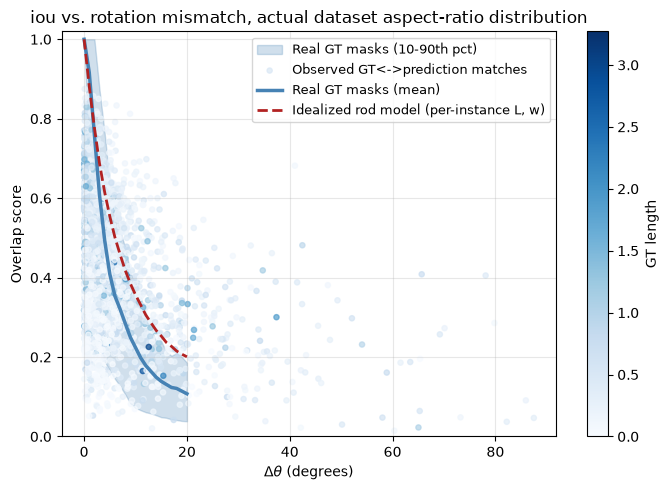

In [80]:
importlib.reload(fn)

fn.plot_results(df, observed_df, "iou", "fig_iou_vs_theta_DSB_all_predlength.png")

## Quick manual sanity check (mean curves only, no percentile band / observed overlay)

Kept from the original notebook as a lightweight cross-check against `plot_results` above.

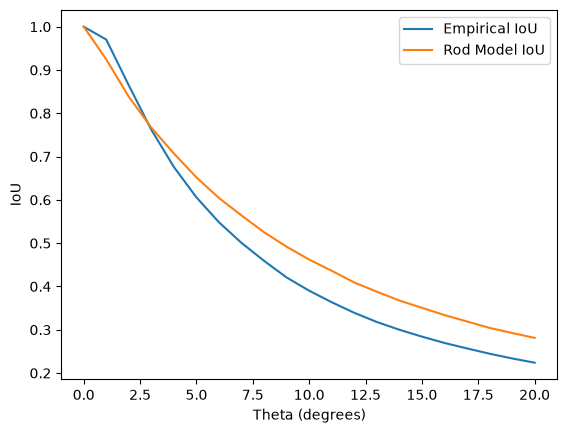

In [ ]:
import matplotlib.pyplot as plt

mean_theta_iou_df = df.groupby("theta")[["empirical_overlap_score", "rod_model_overlap_score"]].mean()
plt.plot(mean_theta_iou_df.index, mean_theta_iou_df["empirical_overlap_score"], label="Empirical overlap_score")
plt.plot(mean_theta_iou_df.index, mean_theta_iou_df["rod_model_overlap_score"], label="Rod Model overlap_score")
plt.xlabel("Theta (degrees)")
plt.ylabel("IoU")
plt.legend()
plt.show()


# Matching with clDICE

In [10]:
max_instances = 1000
importlib.reload(fn)
df = fn.run_rotation_sweep(os.path.join(path_gt, gt_json), scoring_method='clDice', max_instances=max_instances)
print(df.groupby("theta")[["empirical_overlap_score", "rod_model"]].mean())

loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
       empirical_overlap_score  rod_model
theta                                    
0                     1.000000   1.000000
1                     0.984143   0.999703
2                     0.920675   0.988369
3                     0.850791   0.958775
4                     0.785804   0.920509
5                     0.727821   0.876356
6                     0.677390   0.830418
7                     0.634542   0.787379
8                     0.595046   0.746862
9                     0.556673   0.706996
10                    0.524546   0.673637
11                    0.497362   0.641599
12                    0.470509   0.613506
13                    0.446589   0.586618
14                    0.425202   0.557161
15                    0.406119   0.535286
16                    0.389630   0.512889
17                    0.374999   0.493064
18                    0.361618   0.474345
19                    0.346989   0.

       empirical_overlap_score  rod_model
theta                                    
0                     1.000000   1.000000
1                     0.984143   0.999703
2                     0.920675   0.988369
3                     0.850791   0.958775
4                     0.785804   0.920509
5                     0.727821   0.876356
6                     0.677390   0.830418
7                     0.634542   0.787379
8                     0.595046   0.746862
9                     0.556673   0.706996
10                    0.524546   0.673637
11                    0.497362   0.641599
12                    0.470509   0.613506
13                    0.446589   0.586618
14                    0.425202   0.557161
15                    0.406315   0.535286
16                    0.390216   0.512889
17                    0.376129   0.493064
18                    0.363254   0.474345
19                    0.349967   0.455523
20                    0.337234   0.439181


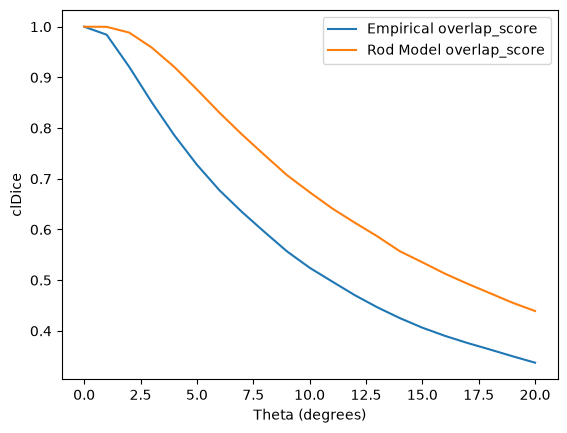

In [26]:
print(df.groupby("theta")[["empirical_overlap_score", "rod_model"]].mean())
import matplotlib.pyplot as plt

mean_theta_iou_df = df.groupby("theta")[["empirical_overlap_score", "rod_model"]].mean()
plt.plot(mean_theta_iou_df.index, mean_theta_iou_df["empirical_overlap_score"], label="Empirical overlap_score")
plt.plot(mean_theta_iou_df.index, mean_theta_iou_df["rod_model"], label="Rod Model overlap_score")
plt.xlabel("Theta (degrees)")
plt.ylabel("clDice")
plt.legend()
plt.show()

In [12]:
importlib.reload(fn)
observed_df = fn.match_gt_pred_observed_points(
    os.path.join(path_gt, gt_json), os.path.join(path_pred, pred_json), scoring_method="clDice", debug_plot_path="debug_plots_clDice", debug_n_examples=8
)

loading annotations into memory...
Done (t=0.17s)
creating index...
index created!
loading annotations into memory...
Done (t=0.45s)
creating index...
index created!


Processing: 100%|██████████| 30/30 [23:16<00:00, 46.54s/it]


Saved debug plot to debug_plots_clDice


In [13]:
importlib.reload(fn)
fn.match_gt_pred_observed_points(
    os.path.join(path_gt, gt_json), os.path.join(path_pred, pred_json), scoring_method="clDice", debug_plot_path="debug_plots_clDice", debug_n_examples=8
)

loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
loading annotations into memory...
Done (t=0.47s)
creating index...
index created!


Processing: 100%|██████████| 30/30 [17:13<00:00, 34.44s/it]


Saved debug plot to debug_plots_clDice


,filename,gt_image_id,pred_image_id,gt_ann_id,pred_ann_id,gt_ori,pred_ori,gt_length,pred_length,observed_theta_diff,observed_length_diff,observed_overlap_score
0,1293-22_3_2_20230306222551.tif,3,1,209,143,10.226794,10.105746,0.501110,0.548263,0.121049,0.047153,0.875000
1,1293-22_3_2_20230306222551.tif,3,1,210,126,74.678973,76.570554,0.792116,0.650658,1.891581,0.141458,0.627395
2,1293-22_3_2_20230306222551.tif,3,1,211,139,60.313288,56.132692,0.582012,0.598192,4.180596,0.016180,0.561728
3,1293-22_3_2_20230306222551.tif,3,1,212,130,107.829634,109.717049,0.647307,0.580623,1.887415,0.066684,0.579957
4,1293-22_3_2_20230306222551.tif,3,1,213,129,37.546435,35.241015,0.586751,0.633903,2.305420,0.047153,0.816786
...,...,...,...,...,...,...,...,...,...,...,...,...
2660,400-1605-W8_map_00049_top_right.tif,130,30,9513,3840,104.678877,100.278023,0.039062,0.105746,4.400854,0.066684,0.800000
2661,400-1605-W8_map_00049_top_right.tif,130,30,9514,3837,121.098685,119.692239,0.074774,0.460085,1.406446,0.385311,0.709677
2662,400-1605-W8_map_00049_top_right.tif,130,30,9515,3836,73.109874,72.403246,0.086215,0.744964,0.706627,0.658748,0.614597
2663,400-1605-W8_map_00049_top_right.tif,130,30,9516,3848,49.925094,40.862054,0.157638,0.138107,9.063041,0.019531,0.519481


In [14]:
observed_df

,filename,gt_image_id,pred_image_id,gt_ann_id,pred_ann_id,gt_ori,pred_ori,gt_length,pred_length,observed_theta_diff,observed_length_diff,observed_overlap_score
0,1293-22_3_2_20230306222551.tif,3,1,209,143,10.226794,10.105746,0.501110,0.548263,0.121049,0.047153,0.875000
1,1293-22_3_2_20230306222551.tif,3,1,210,126,74.678973,76.570554,0.792116,0.650658,1.891581,0.141458,0.627395
2,1293-22_3_2_20230306222551.tif,3,1,211,139,60.313288,56.132692,0.582012,0.598192,4.180596,0.016180,0.561728
3,1293-22_3_2_20230306222551.tif,3,1,212,130,107.829634,109.717049,0.647307,0.580623,1.887415,0.066684,0.579957
4,1293-22_3_2_20230306222551.tif,3,1,213,129,37.546435,35.241015,0.586751,0.633903,2.305420,0.047153,0.816786
...,...,...,...,...,...,...,...,...,...,...,...,...
2660,400-1605-W8_map_00049_top_right.tif,130,30,9513,3840,104.678877,100.278023,0.039062,0.105746,4.400854,0.066684,0.800000
2661,400-1605-W8_map_00049_top_right.tif,130,30,9514,3837,121.098685,119.692239,0.074774,0.460085,1.406446,0.385311,0.709677
2662,400-1605-W8_map_00049_top_right.tif,130,30,9515,3836,73.109874,72.403246,0.086215,0.744964,0.706627,0.658748,0.614597
2663,400-1605-W8_map_00049_top_right.tif,130,30,9516,3848,49.925094,40.862054,0.157638,0.138107,9.063041,0.019531,0.519481


In [15]:
observed_df

,filename,gt_image_id,pred_image_id,gt_ann_id,pred_ann_id,gt_ori,pred_ori,gt_length,pred_length,observed_theta_diff,observed_length_diff,observed_overlap_score
0,1293-22_3_2_20230306222551.tif,3,1,209,143,10.226794,10.105746,0.501110,0.548263,0.121049,0.047153,0.875000
1,1293-22_3_2_20230306222551.tif,3,1,210,126,74.678973,76.570554,0.792116,0.650658,1.891581,0.141458,0.627395
2,1293-22_3_2_20230306222551.tif,3,1,211,139,60.313288,56.132692,0.582012,0.598192,4.180596,0.016180,0.561728
3,1293-22_3_2_20230306222551.tif,3,1,212,130,107.829634,109.717049,0.647307,0.580623,1.887415,0.066684,0.579957
4,1293-22_3_2_20230306222551.tif,3,1,213,129,37.546435,35.241015,0.586751,0.633903,2.305420,0.047153,0.816786
...,...,...,...,...,...,...,...,...,...,...,...,...
2660,400-1605-W8_map_00049_top_right.tif,130,30,9513,3840,104.678877,100.278023,0.039062,0.105746,4.400854,0.066684,0.800000
2661,400-1605-W8_map_00049_top_right.tif,130,30,9514,3837,121.098685,119.692239,0.074774,0.460085,1.406446,0.385311,0.709677
2662,400-1605-W8_map_00049_top_right.tif,130,30,9515,3836,73.109874,72.403246,0.086215,0.744964,0.706627,0.658748,0.614597
2663,400-1605-W8_map_00049_top_right.tif,130,30,9516,3848,49.925094,40.862054,0.157638,0.138107,9.063041,0.019531,0.519481


In [16]:
df

,ann_id,theta,length,width,aspect_ratio,empirical_overlap_score,rod_model
0,1,0,95.798990,2.404061,39.848818,1.000000,1.000000
1,1,1,95.798990,2.404061,39.848818,0.779817,1.000000
2,1,1,95.798990,2.404061,39.848818,0.776000,1.000000
3,1,2,95.798990,2.404061,39.848818,0.617873,0.757938
4,1,2,95.798990,2.404061,39.848818,0.630899,0.757938
...,...,...,...,...,...,...,...
40954,1000,18,9.899495,2.710080,3.652842,0.873864,0.939759
40955,1000,19,9.899495,2.710080,3.652842,0.815534,0.898876
40956,1000,19,9.899495,2.710080,3.652842,0.844131,0.898876
40957,1000,20,9.899495,2.710080,3.652842,0.815534,0.921348


Saved figure to fig_clDice_vs_theta_DSB_all__.png


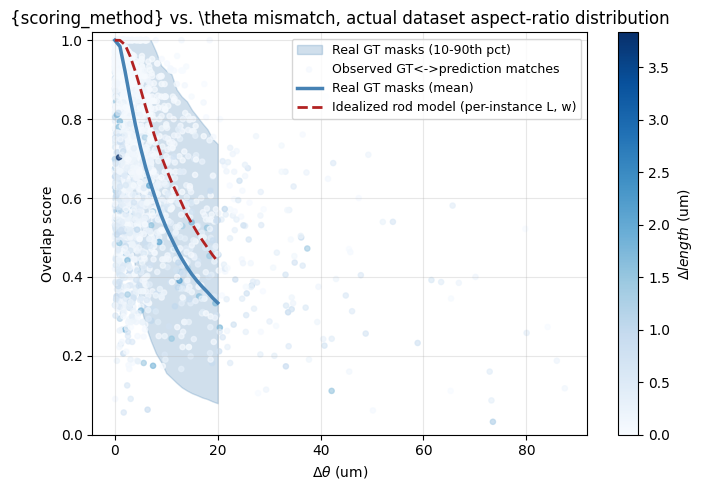

In [17]:
importlib.reload(fn)
    
fn.plot_results(df, observed_df, "clDice", "fig_clDice_vs_theta_DSB_all__.png")


In [18]:
df

,ann_id,theta,length,width,aspect_ratio,empirical_overlap_score,rod_model
0,1,0,95.798990,2.404061,39.848818,1.000000,1.000000
1,1,1,95.798990,2.404061,39.848818,0.779817,1.000000
2,1,1,95.798990,2.404061,39.848818,0.776000,1.000000
3,1,2,95.798990,2.404061,39.848818,0.617873,0.757938
4,1,2,95.798990,2.404061,39.848818,0.630899,0.757938
...,...,...,...,...,...,...,...
40954,1000,18,9.899495,2.710080,3.652842,0.873864,0.939759
40955,1000,19,9.899495,2.710080,3.652842,0.815534,0.898876
40956,1000,19,9.899495,2.710080,3.652842,0.844131,0.898876
40957,1000,20,9.899495,2.710080,3.652842,0.815534,0.921348


In [19]:
df

,ann_id,theta,length,width,aspect_ratio,empirical_overlap_score,rod_model
0,1,0,95.798990,2.404061,39.848818,1.000000,1.000000
1,1,1,95.798990,2.404061,39.848818,0.779817,1.000000
2,1,1,95.798990,2.404061,39.848818,0.776000,1.000000
3,1,2,95.798990,2.404061,39.848818,0.617873,0.757938
4,1,2,95.798990,2.404061,39.848818,0.630899,0.757938
...,...,...,...,...,...,...,...
40954,1000,18,9.899495,2.710080,3.652842,0.873864,0.939759
40955,1000,19,9.899495,2.710080,3.652842,0.815534,0.898876
40956,1000,19,9.899495,2.710080,3.652842,0.844131,0.898876
40957,1000,20,9.899495,2.710080,3.652842,0.815534,0.921348


In [ ]:
from pycocotools.coco import COCO

importlib.reload(fn)

k = 10
TITLE_EXPERIMENT = "debug_plots_max_length_subset_cldice"
subset_df = (
    observed_df[
        # (observed_df["observed_overlap_score"] < 0.5)
        # & (observed_df["observed_theta_diff"] < 5) &
         (observed_df["observed_length_diff"] > 1.5)
    ]
    .sample(k)
)

# Load COCO annotations
gt_coco = COCO(os.path.join(path_gt, gt_json))
pred_coco = COCO(os.path.join(path_pred, pred_json))

debug_crops = []

for _, row in subset_df.iterrows():

    gt_ann = gt_coco.loadAnns([int(row["gt_ann_id"])])[0]
    pred_ann = pred_coco.loadAnns([int(row["pred_ann_id"])])[0]

    gt_mask = fn.ann_to_mask(gt_coco, gt_ann)
    pred_mask = fn.ann_to_mask(pred_coco, pred_ann)

    debug_crops.append({
        "filename": row["filename"],
        "gt_image_id": row["gt_image_id"],
        "pred_image_id": row["pred_image_id"],

        "gt_ann_id": row["gt_ann_id"],
        "pred_ann_id": row["pred_ann_id"],

        "gt_mask": gt_mask,
        "pred_mask": pred_mask,

        "gt_ori": row["gt_ori"],
        "pred_ori": row["pred_ori"],

        "gt_length": row["gt_length"],
        "pred_length": row["pred_length"],

        "observed_theta_diff": row["observed_theta_diff"],
        "observed_length_diff": row["observed_length_diff"],
        "observed_overlap_score": row["observed_overlap_score"],
    })

fn._plot_matched_examples(
    debug_crops,
    TITLE_EXPERIMENT,
    len(debug_crops),
    "observed_theta_diff",
    "observed_overlap_score",
    figsize=(6.0, 4.0),
)


loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
loading annotations into memory...
Done (t=0.52s)
creating index...
index created!
Saved debug plot to debug_plots_max_length_subset_cldice


: 